# scPhyloGRN: your first prediction, step by step

This beginner tutorial answers: **how does the trained model score a directed pair of genes?**
You will load real weights, predict five illustrative pairs, draw the results, change the queries, and save a CSV. No training or GPU is needed.

Run the bundled example unchanged once; then edit the input in section 7.
中文操作指南：[START_HERE_ZH.md](START_HERE_ZH.md).

## What is being loaded?

- A **gene pair** contains a source and a target: A → B differs from B → A.
- **Weights** are numbers learned during training, not randomly initialized toy parameters.
- An **embedding** is a learned numerical description of a gene, already computed by the trained encoder.
- The **decoder** combines the two gene embeddings to calculate a score.

The cache represents **embryo1, seed 42, selected epoch 17**. You may change queries among cached genes, but cannot input new genes, cells, or expression matrices here. Full graph reconstruction is in `inference_demo.ipynb` in the full repository, not the small ZIP.


## 0. Open the right environment

Unzip `scPhyloGRN_quickstart.zip` and keep its files together. The notebook alone is not enough.

**Personal computer:** in a terminal, change to the extracted directory, create an environment, and launch JupyterLab. Python 3.10 is a suggested starting point; the accompanying test record lists the environment actually tested.

```bash
python -m venv .venv
# Linux/macOS:
source .venv/bin/activate
# Windows PowerShell instead:
# .venv/Scripts/Activate.ps1
python -m pip install -r requirements-quickstart.txt
python -m jupyter lab
```

**This HPC cluster:** use JupyterHub with an allocated CPU compute node (2 cores and 2 GB RAM for the small example). Install dependencies only in that allocated session if needed. Never start Jupyter or run Python on the login node. In the full repository, `sbatch run_quickstart.sbatch` validates a freshly packaged copy non-interactively and produces an executed notebook.

Open `scPhyloGRN_quickstart.ipynb` in JupyterLab and select the kernel belonging to your installed environment. Installing packages in a terminal does not switch the notebook kernel.

### Running cells

Text cells explain the next action; code cells have counters such as `[1]`. Click a code cell and press **Shift + Enter**. Wait for `[*]` to become a number before proceeding.

Run top to bottom. After a kernel restart, use **Restart Kernel and Run All Cells**. Do not skip directly to prediction. No cell below installs software or trains a model.


### 0.1 Check the allocation first

Before loading scientific libraries, check the local cluster rule. On a personal computer without Slurm, no allocation is required. This is a safeguard, not a way to relocate your kernel: never set job variables manually to bypass it.


In [1]:
import os
import shutil
import socket

if shutil.which("sbatch") and not os.environ.get("SLURM_JOB_ID"):
    raise RuntimeError("Use an allocated compute-node kernel, never the login node.")
print("Host:", socket.gethostname())
print("Slurm job:", os.environ.get("SLURM_JOB_ID", "not a Slurm session"))


Host: stat1
Slurm job: 18041


### 0.2 Import file-handling tools

These tools locate files and measure elapsed time. The printed interpreter helps diagnose a wrong kernel.


In [2]:
from pathlib import Path
import sys
import json
import time

print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)


Python: 3.8.20
Interpreter: /export/home/mengrui/.conda/envs/mycode_py38/bin/python


### 0.3 Import prediction and plotting libraries

Pandas handles tables, NumPy checks numbers, PyTorch runs the model, and Matplotlib draws figures. A `ModuleNotFoundError` means your selected kernel lacks a dependency; return to section 0.


In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

print("PyTorch:", torch.__version__)
print("Matplotlib:", matplotlib.__version__)


PyTorch: 2.4.0
Matplotlib: 3.7.2


## 1. Find the bundle

### 1.1 Locate the extracted folder

If this check fails, replace `Path.cwd()` with `Path("/your/extracted/folder")`. Windows paths may use forward slashes, such as `Path("C:/Users/name/scPhyloGRN_quickstart")`.


In [4]:
BUNDLE_DIR = Path.cwd().resolve()
required = ["quickstart_utils.py", "tutorial_plots.py", "model/quickstart/manifest.json"]
missing = [name for name in required if not (BUNDLE_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f"Set BUNDLE_DIR to the extracted folder. Missing: {missing}")
CACHE = BUNDLE_DIR / "model" / "quickstart"
print("Bundle:", BUNDLE_DIR)


Bundle: /tmp/grn-quickstart-iDu0PK


### 1.2 Import the small helpers

`CachedPredictor` loads weights and computes predictions. `tutorial_plots.py` contains only drawing routines; its source is included so you can inspect it without long plotting cells interrupting the tutorial.

The predictor always uses CPU. Limit its threads to the allocated cores.


In [5]:
sys.path.insert(0, str(BUNDLE_DIR))
from quickstart_utils import CachedPredictor
from tutorial_plots import plot_query_pairs, plot_scores

threads = min(4, int(os.environ.get("SLURM_CPUS_PER_TASK", "2")))
torch.set_num_threads(threads)
print("CPU threads:", threads)


CPU threads: 2


### 1.3 What runs here?

The encoder embeddings were prepared in advance. This notebook uses them with the trained decoder to compute new scores for your gene pairs.


## 2. Load the trained model

### 2.1 Verify files and load weights

This call verifies SHA-256 checksums for embeddings, weights and metadata, checks dimensions, and puts the decoder in evaluation mode. Checksums detect inconsistent files, not the trustworthiness of an unknown download.


In [6]:
started = time.perf_counter()
model = CachedPredictor(CACHE)
print(f"Model loaded on CPU in {time.perf_counter() - started:.2f} seconds.")


Model loaded on CPU in 0.03 seconds.


### 2.2 Inspect model identity

Expect embryo1, 10,667 genes, 128 numbers per embedding, and selected epoch 17. This identifies the model; it is not a new performance evaluation.


In [7]:
identity = {
    "context": model.metadata["context"],
    "genes": len(model.genes),
    "embedding dimensions": model.hidden.shape[1],
    "selected epoch": model.metadata["best_epoch"],
    "training split": model.metadata["training_split"],
    "device": str(model.hidden.device),
}
display(pd.Series(identity, name="Model information"))


context                 embryo1 fixed expression and lineage graph
genes                                                        10667
embedding dimensions                                           128
selected epoch                                                  17
training split                                              random
device                                                         cpu
Name: Model information, dtype: object

### 2.3 Inspect accepted gene identifiers

Names are case-sensitive. The first ten rows illustrate the format, not gene importance. Find the full list in `model/quickstart/genes.csv`.


In [8]:
gene_table = pd.DataFrame({"gene": model.genes})
display(gene_table.head(10))
print("Number of accepted genes:", len(gene_table))


,gene
0,0610007P14RIK
1,0610009B22RIK
2,0610009O20RIK
3,0610010F05RIK
4,0610010K14RIK
5,0610011F06RIK
6,0610012G03RIK
7,0610030E20RIK
8,0610037L13RIK
9,0610040J01RIK


Number of accepted genes: 10667


## 3. Inspect the demonstration input

### 3.1 Read five example pairs

| Column | Meaning | Example |
|---|---|---|
| `gene_i` | Source gene | AEBP2 |
| `gene_j` | Target gene | PALB2 |

The examples have no evaluation labels and may overlap training/reference data. Sources are not necessarily annotated transcription factors; use a curated TF list for TF–target analysis.


In [9]:
example_pairs = pd.read_csv(CACHE / "example_pairs.csv", dtype=str)
display(example_pairs)
print("Pairs to score:", len(example_pairs))


,gene_i,gene_j
0,AEBP2,PALB2
1,PALB2,AEBP2
2,DCTN5,VAMP4
3,VAMP4,EXOC2
4,EXOC2,RPL22


Pairs to score: 5


### 3.2 Visualize each query

**Figure 1 — query directions, not a discovered network.** Each arrow corresponds to one input row. Equal arrow styles are intentional: no predictions or biological evidence are encoded here.


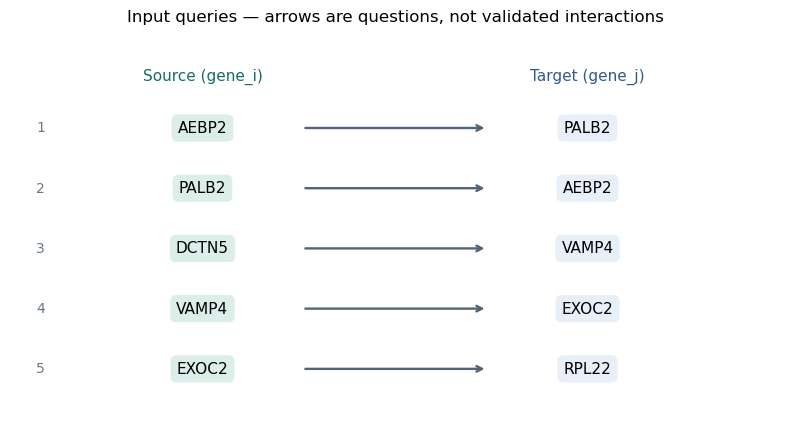

In [10]:
query_figure = plot_query_pairs(example_pairs)
plt.show()


## 4. Make your first prediction

### 4.1 Compute scores

This is the actual inference call. It looks up embeddings and runs the trained decoder; it does not train, rebuild the graph, or read expected answers.


In [11]:
started = time.perf_counter()
example_predictions = model.predict(example_pairs)
elapsed = time.perf_counter() - started
print(f"Scored {len(example_predictions)} pairs in {elapsed:.4f} seconds.")


Scored 5 pairs in 0.0122 seconds.


### 4.2 View the results

Expect one result per input row, in the original order. Display rounding affects only the screen, not stored values.


In [12]:
display(example_predictions.round(6))


,gene_i,gene_j,logit,probability,calibrated_probability
0,AEBP2,PALB2,5.832315,0.997077,0.996949
1,PALB2,AEBP2,-8.799403,0.000151,0.000161
2,DCTN5,VAMP4,-11.704207,0.000008,0.000009
3,VAMP4,EXOC2,-10.158415,0.000039,0.000042
4,EXOC2,RPL22,-12.815870,0.000003,0.000003


### 4.3 Interpret one result

| Score | Meaning |
|---|---|
| `logit` | Raw decoder output, not limited to 0–1. |
| `probability` | Sigmoid of the raw score. |
| `calibrated_probability` | Sigmoid after dividing the logit by the stored validation temperature. |

Larger values mean greater model support within the fixed embryo1 context. Calibration used sampled validation edges. A score of 0.99 does **not** establish regulation with 99% biological probability. No universal biological threshold of 0.5 is justified.


In [13]:
first = example_predictions.iloc[0]
print(f"Query: {first.gene_i} → {first.gene_j}")
print(f"Raw score: {first.logit:.6f}")
print(f"Calibrated model score: {first.calibrated_probability:.6f}")


Query: AEBP2 → PALB2
Raw score: 5.832315
Calibrated model score: 0.996949


## 5. Plot the example predictions

**Figure 2 — model scores, not a performance evaluation.** The left panel shows logits and the right panel calibrated scores on a fixed 0–1 axis. Both use the same order, sorted by calibrated score.

Scores near 0 or 1 may hide differences; inspect the logits alongside them. Very small labels use scientific notation (for example, 1e-5 means 0.00001) rather than rounding to zero. No error bars are shown because these are single-model outputs, not repeated measurements or experimentally verified interactions.


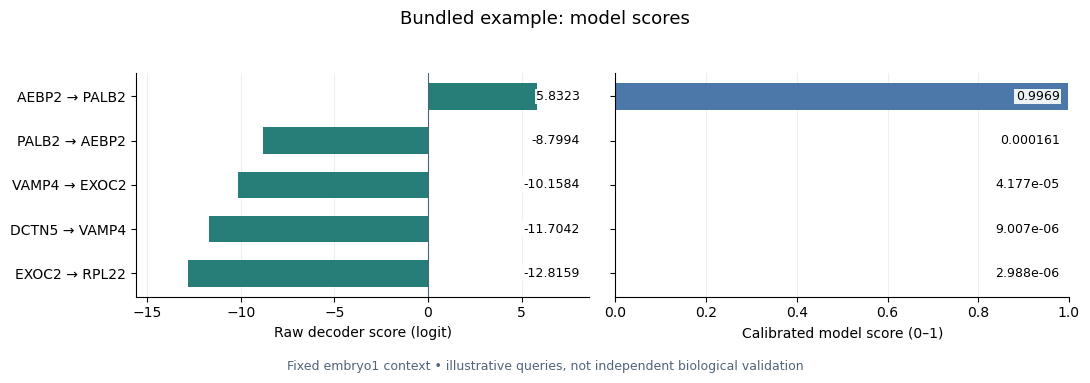

In [14]:
score_figure = plot_scores(example_predictions, title="Bundled example: model scores")
plt.show()


## 6. Verify the bundled example

### 6.1 Load expected values

Only now are reference scores read. They check computation; they do not produce predictions. Do not edit them to make a failing test pass. Custom queries in section 7 are not compared against this fixture.


In [15]:
expected = pd.read_csv(CACHE / "expected_predictions.csv")
display(expected.round(6))


,gene_i,gene_j,logit,probability,calibrated_probability
0,AEBP2,PALB2,5.832315,0.997077,0.996949
1,PALB2,AEBP2,-8.799403,0.000151,0.000161
2,DCTN5,VAMP4,-11.704207,0.000008,0.000009
3,VAMP4,EXOC2,-10.158415,0.000039,0.000042
4,EXOC2,RPL22,-12.815870,0.000003,0.000003


### 6.2 Check pair identities and order

This checks that we are comparing the same rows. You should see a PASS message.


In [16]:
pair_columns = ["gene_i", "gene_j"]
pd.testing.assert_frame_equal(
    example_predictions[pair_columns], expected[pair_columns]
)
print("PASS: pair identities and order match.")


PASS: pair identities and order match.


### 6.3 Check numerical agreement

Small floating-point differences are normal. The relative tolerance is `1e-4`, absolute tolerance `1e-5`. If the check fails, preserve the full error and check for mixed bundle versions or environment differences; do not disable the check.


In [17]:
score_columns = ["logit", "probability", "calibrated_probability"]
np.testing.assert_allclose(
    example_predictions[score_columns], expected[score_columns],
    rtol=1e-4, atol=1e-5,
)
print("PASS: predictions match the archived example.")


PASS: predictions match the archived example.


### 6.4 Inspect the preparation-time record

This report was produced when the cache was built; it is **not rerun here**. Comparisons covered GPU scoring and 500 sampled rows from the original training export. These are computational consistency checks, not independent biological validation.


In [18]:
validation = json.loads((CACHE / "validation.json").read_text())
display(pd.Series(validation, name="Cache preparation record"))


compared_pairs                                133
max_abs_logit_error                      0.000003
training_export_pairs                         500
training_export_max_abs_logit_error      0.000004
previous_fixture_max_abs_logit_change    0.551977
cpu_scoring_seconds                      0.012676
cpu_threads                                     4
job_id                                      18008
cache_bytes                               6402031
Name: Cache preparation record, dtype: object

## 7. Predict your own pairs

### 7.1 Edit a tiny table

Change names inside quotation marks or add rows. Keep the column names. The default rows work unchanged. Do not edit `example_pairs` or the reference CSV: custom work stays separate.


In [19]:
my_pairs = pd.DataFrame(
    [("AEBP2", "PALB2"), ("PALB2", "AEBP2")],
    columns=["gene_i", "gene_j"],
)
display(my_pairs)


,gene_i,gene_j
0,AEBP2,PALB2
1,PALB2,AEBP2


### 7.2 Optional: read a CSV instead

Leave `CUSTOM_CSV = None` to keep the table above. Otherwise set it to `BUNDLE_DIR / "my_gene_pairs.csv"`. Your file must look like:

```csv
gene_i,gene_j
AEBP2,PALB2
PALB2,AEBP2
```

The next cell replaces `my_pairs` only when a file path is supplied.


In [20]:
CUSTOM_CSV = None

if CUSTOM_CSV is not None:
    my_pairs = pd.read_csv(CUSTOM_CSV, dtype=str)
display(my_pairs)


,gene_i,gene_j
0,AEBP2,PALB2
1,PALB2,AEBP2


### 7.3 Validate before scoring

Unknown/missing names, surrounding spaces, empty input, duplicate directed pairs, and self-pairs produce explanatory errors. Names are case-sensitive. To remove duplicates intentionally, edit your input or use `my_pairs = my_pairs.drop_duplicates()`.

Passing this check means the input is usable, not that the queries are biologically appropriate.


In [21]:
my_pairs = model.validate_pairs(my_pairs)
print(f"Input accepted: {len(my_pairs)} directed pairs.")


Input accepted: 2 directed pairs.


### 7.4 Compute your predictions

New queries still use the same expression/lineage context; they are not necessarily unseen training examples.


In [22]:
predictions = model.predict(my_pairs)
display(predictions.round(6))


,gene_i,gene_j,logit,probability,calibrated_probability
0,AEBP2,PALB2,5.832314,0.997077,0.996949
1,PALB2,AEBP2,-8.799404,0.000151,0.000161


### 7.5 Plot your top queries

Display at most ten rows to keep labels readable. All queries remain in the results table. This is ranking within your list, not genome-wide ranking.


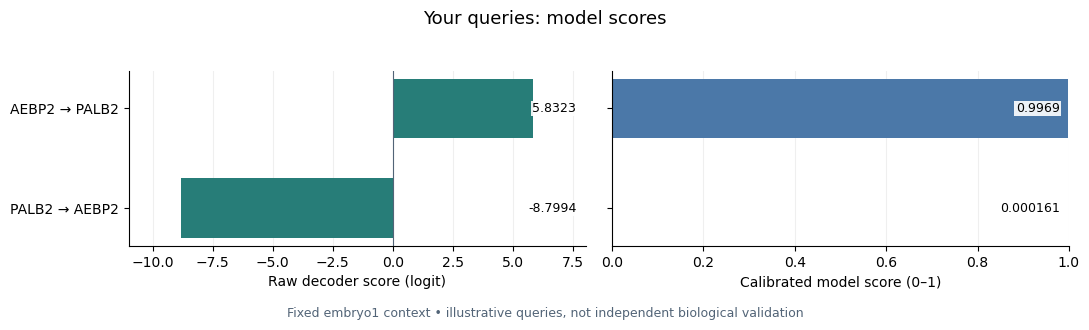

In [23]:
TOP_K = 10
custom_figure = plot_scores(predictions, top_k=TOP_K, title="Your queries: model scores")
plt.show()


## 8. Save and inspect outputs

### 8.1 Create a folder for this run

A timestamped folder separates runs. If a folder already exists, creation stops rather than overwriting. Model/cache files stay unchanged.


In [24]:
from datetime import datetime

run_id = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
OUTPUT_DIR = BUNDLE_DIR / "results" / run_id
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
print("Output folder:", OUTPUT_DIR)


Output folder: /tmp/grn-quickstart-iDu0PK/results/20260907_221143_138649


### 8.2 Save input-order and ranked tables

CSV files open in spreadsheet software or Pandas. `index=False` avoids an extra row-number column. Scores are saved without display rounding.


In [25]:
ranked = predictions.sort_values("calibrated_probability", ascending=False)
predictions.to_csv(OUTPUT_DIR / "my_predictions.csv", index=False)
ranked.to_csv(OUTPUT_DIR / "my_predictions_ranked.csv", index=False)
print("Saved both prediction tables.")


Saved both prediction tables.


### 8.3 Save figures

PNG files are easy to preview; PDF preserves vector text and shapes. These tutorial figures do not demonstrate accuracy. Saving an existing figure does not repeat prediction.


In [26]:
query_figure.savefig(OUTPUT_DIR / "example_queries.png", dpi=160, bbox_inches="tight")
score_figure.savefig(OUTPUT_DIR / "example_scores.png", dpi=160, bbox_inches="tight")
custom_figure.savefig(OUTPUT_DIR / "my_scores.png", dpi=160, bbox_inches="tight")
custom_figure.savefig(OUTPUT_DIR / "my_scores.pdf", bbox_inches="tight")
print("Saved three PNG figures and one PDF.")


Saved three PNG figures and one PDF.


### 8.4 Read the saved CSV back

Confirm the file on disk contains the computed predictions. This does not compare custom queries with the bundled reference.


In [27]:
saved = pd.read_csv(OUTPUT_DIR / "my_predictions.csv")
pd.testing.assert_frame_equal(saved[pair_columns], predictions[pair_columns].reset_index(drop=True))
np.testing.assert_allclose(saved[score_columns], predictions[score_columns], rtol=1e-6, atol=1e-7)
display(saved.head())
print("PASS: saved CSV matches your predictions.")


,gene_i,gene_j,logit,probability,calibrated_probability
0,AEBP2,PALB2,5.832314,0.997077,0.996949
1,PALB2,AEBP2,-8.799404,0.000151,0.000161


PASS: saved CSV matches your predictions.


### 8.5 Find the files

In JupyterLab, browse to `results` and the run folder printed above. On JupyterHub, right-click a file and choose Download to save a local copy.


In [28]:
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path.name)
print("Complete output path:", OUTPUT_DIR)


example_queries.png
example_scores.png
my_predictions.csv
my_predictions_ranked.csv
my_scores.pdf
my_scores.png
Complete output path: /tmp/grn-quickstart-iDu0PK/results/20260907_221143_138649


## 9. Next steps and troubleshooting

You have loaded real weights, predicted example and custom pairs, checked consistency, plotted scores, and exported files. To change pairs, rerun **sections 7–8**. After a kernel restart, rerun from section 0.

| Symptom | What to check |
|---|---|
| Allocation error | Launch the notebook kernel on the allocated node. An `srun` terminal does not move an existing kernel. |
| `ModuleNotFoundError` | Install requirements in the allocated environment and select that same kernel. |
| `NameError` | An earlier cell was skipped or the kernel restarted. Run top to bottom. |
| Missing files | Extract the entire ZIP and correct `BUNDLE_DIR`. |
| Unknown gene | Check exact spelling in `genes.csv`; the cache cannot represent new genes. |
| Checksum/reference mismatch | Restore a matching trusted bundle; report package versions and the full error. Do not bypass verification. |
| Kernel restart | Check that you opened `scPhyloGRN_quickstart.ipynb`, inspect memory limits/job logs, and restart from section 0. |
| Bars look similar | Calibrated scores may saturate near 1. Inspect logits; this is not a plotting error. |

### Scope and publication status

The original protocol uses random edge splits and sampled negatives. Examples may overlap training/reference data. A high score is a hypothesis for follow-up, not proof of regulation or causation. Unseen TFs, organisms, and datasets need separate validation.

The small ZIP contains **decoder weights and cached embeddings, not the complete encoder checkpoint or original data**. Full reconstruction requires the full repository's `inference_demo.ipynb`, matching expression/lineage files and checkpoint. Different expression data require a suitable training/transfer workflow.

This remains a local draft: public Zenodo DOI and redistribution licence are not yet assigned here. See `QUICKSTART.md`.
